Columns in dataset: Index(['date', 'Price'], dtype='object')
         date  Price
0  21/09/2024  32.10
1  22/09/2024  32.25
2  23/09/2024  31.07
3  24/09/2024  31.50
4  25/09/2024  32.21
            Price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21


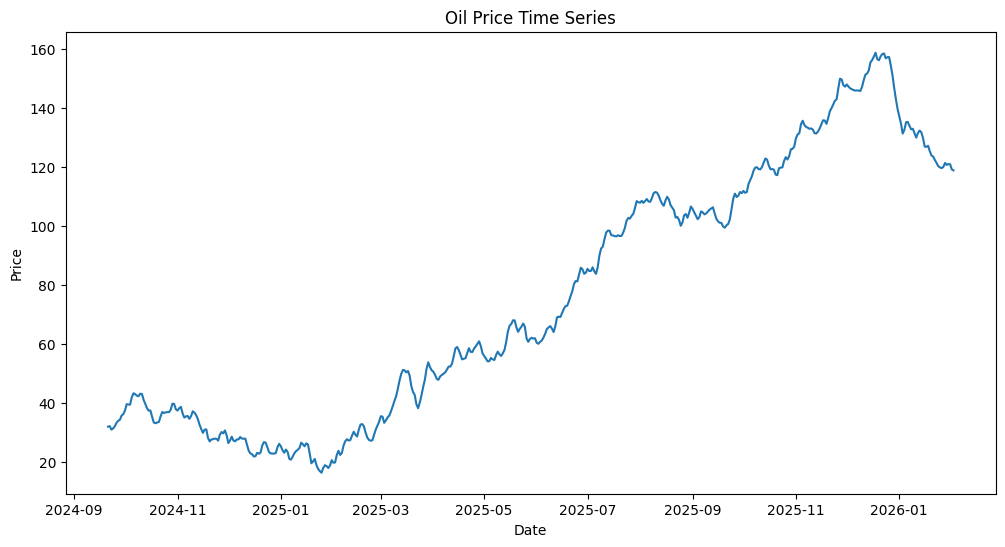

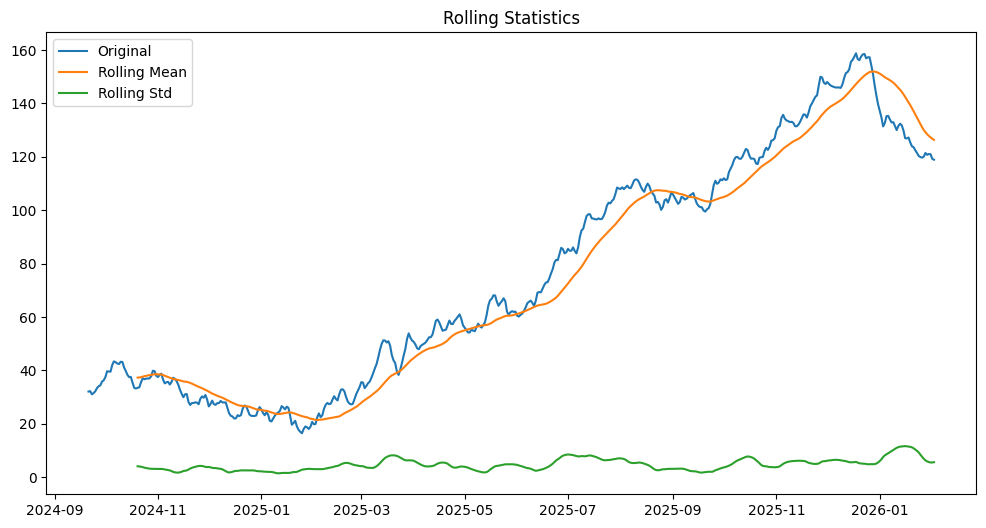

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Critical Value 1% : -3.4439899743408136
Critical Value 5% : -2.8675550551408353
Critical Value 10% : -2.569973792117904
Data is NOT Stationary


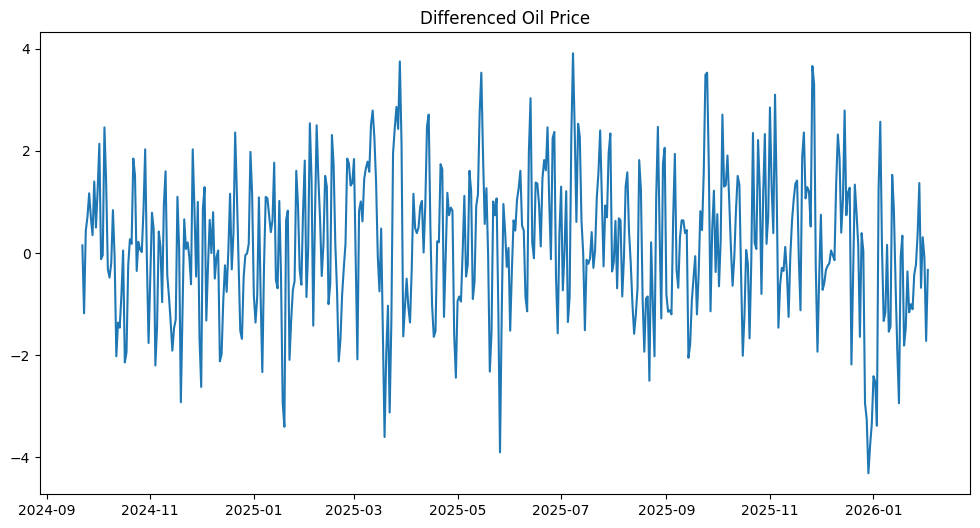

ADF Statistic: -4.541460173486703
p-value: 0.00016536459860957148
Critical Value 1% : -3.4439899743408136
Critical Value 5% : -2.8675550551408353
Critical Value 10% : -2.569973792117904
Data is Stationary


<Figure size 1200x500 with 0 Axes>

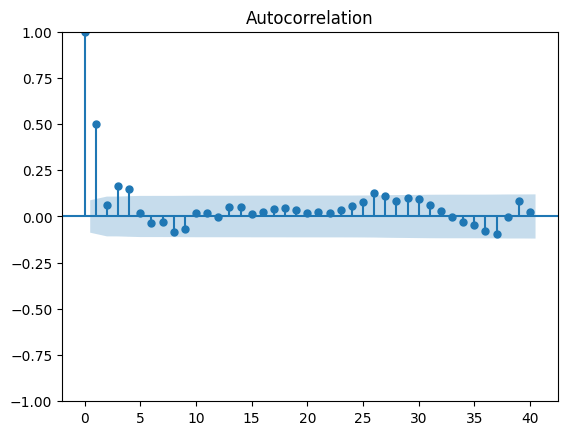

<Figure size 1200x500 with 0 Axes>

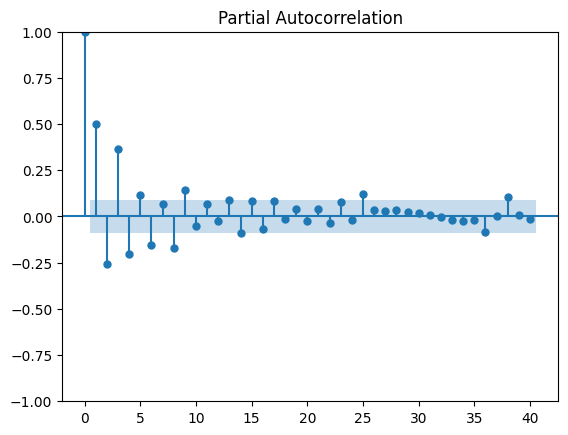

Searching best ARIMA parameters...
Best ARIMA order: (8, 0, 0)
Best AIC: 212.8175505271527
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  399
Model:                 ARIMA(8, 0, 0)   Log Likelihood                 -96.409
Date:                Wed, 11 Mar 2026   AIC                            212.818
Time:                        12:20:00   BIC                            252.707
Sample:                    09-22-2024   HQIC                           228.616
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.5577   3.81e-05   1.59e+06      0.000      60.558      60.558
ar.L1          4.7029   4.04e-06   1.16e

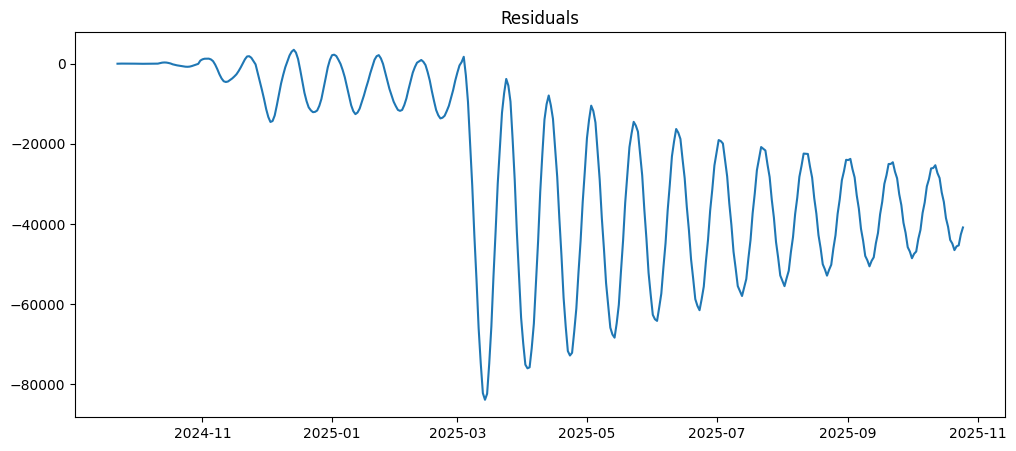

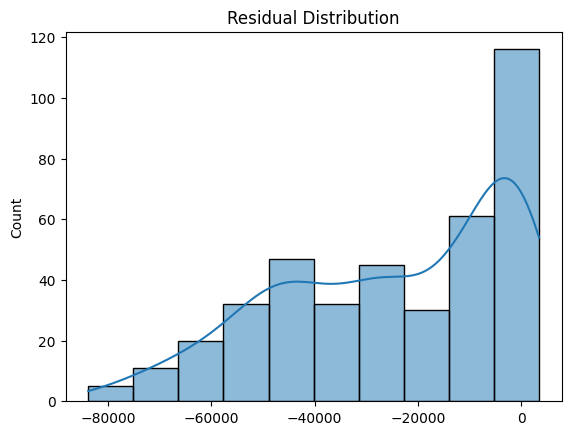

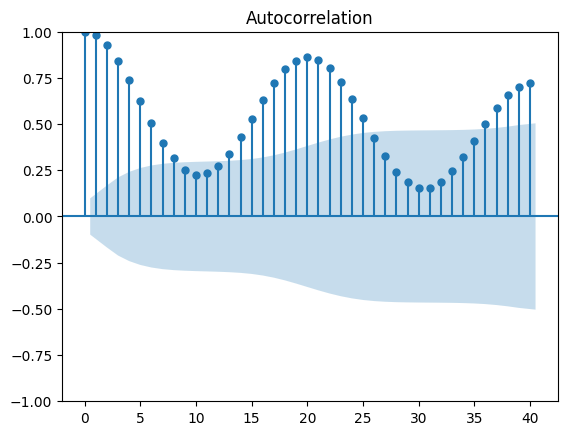

RMSE: 34928.073296785595


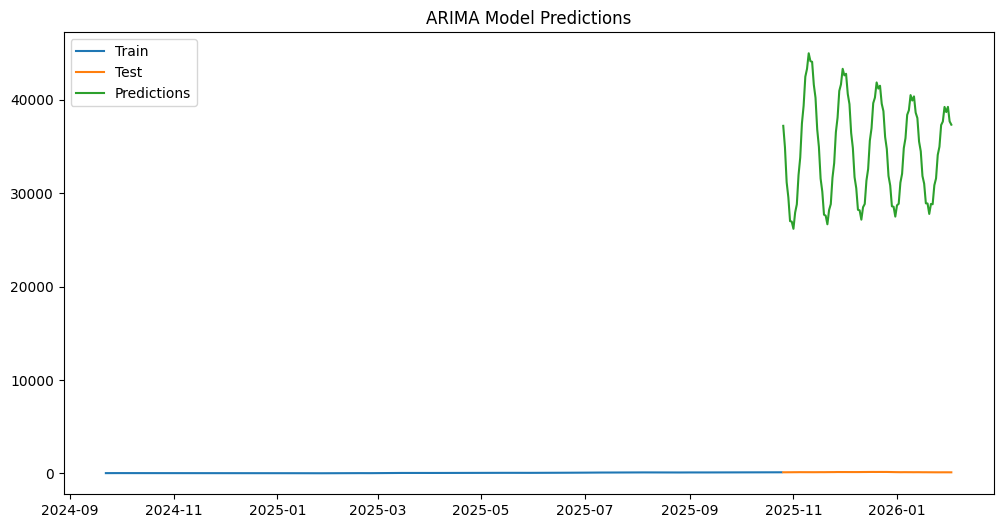

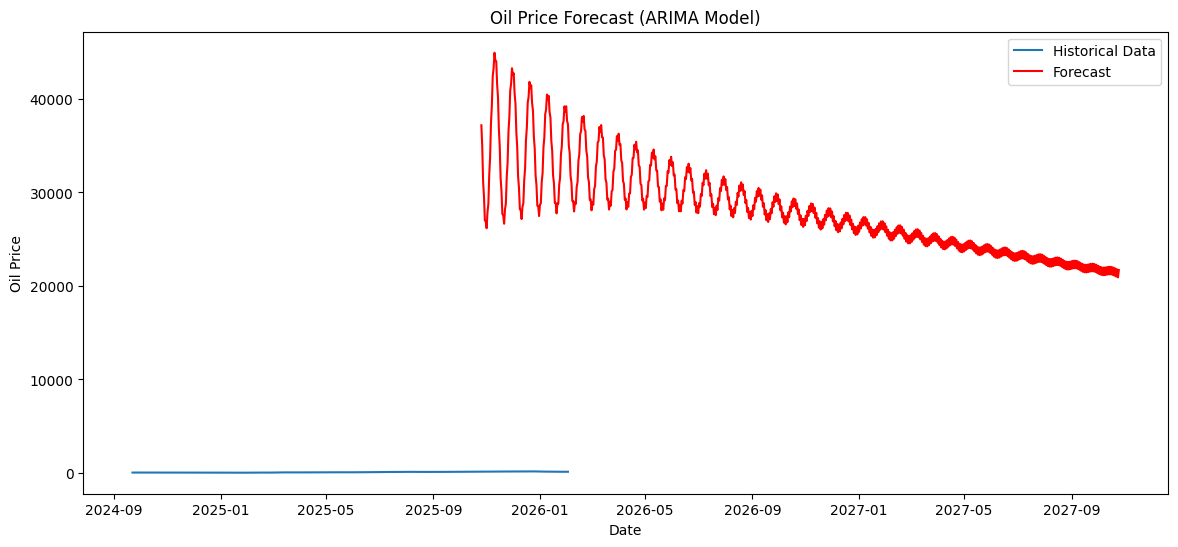

In [1]:

#  Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
import itertools
import warnings

warnings.filterwarnings("ignore")



#  Load Dataset


df = pd.read_csv("oil_prices_2426.csv")

df.columns = df.columns.str.strip()

df.rename(columns={'price (dollars)': 'Price'}, inplace=True)

print("Columns in dataset:", df.columns)

print(df.head())





df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df.dropna()

df.set_index('date', inplace=True)

print(df.head())




#  Exploratory Data Analysis (EDA)


plt.figure(figsize=(12,6))
plt.plot(df['Price'])
plt.title("Oil Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()




#  Rolling Mean and Std


rolling_mean = df['Price'].rolling(window=30).mean()
rolling_std = df['Price'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(df['Price'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.title("Rolling Statistics")
plt.show()




#  ADF Stationarity Test


def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    for key, value in result[4].items():
        print("Critical Value", key, ":", value)

    if result[1] < 0.05:
        print("Data is Stationary")
    else:
        print("Data is NOT Stationary")

adf_test(df['Price'])




#  Differencing (Make Stationary)


df['Price_diff'] = df['Price'].diff()

df = df.dropna()

plt.figure(figsize=(12,6))
plt.plot(df['Price_diff'])
plt.title("Differenced Oil Price")
plt.show()

adf_test(df['Price_diff'])




#  ACF and PACF Plots


plt.figure(figsize=(12,5))
plot_acf(df['Price_diff'], lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Price_diff'], lags=40)
plt.show()




#  Train-Test Split


train_size = int(len(df) * 0.8)

train = df['Price'][:train_size]
test = df['Price'][train_size:]



#  Grid Search for Best ARIMA


p = range(0,9)
d = range(0,3)
q = range(0,9)

pdq = list(itertools.product(p,d,q))

best_aic = float("inf")
best_order = None

print("Searching best ARIMA parameters...")

for param in pdq:

    try:

        model = ARIMA(train, order=param)
        results = model.fit()

        if results.aic < best_aic:

            best_aic = results.aic
            best_order = param

    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)






model = ARIMA(train, order=best_order)
model_fit = model.fit()

print(model_fit.summary())




#  Residual Analysis


residuals = model_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()


sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


plot_acf(residuals, lags=40)
plt.show()




#  Predictions on Test Data


predictions = model_fit.forecast(steps=len(test))




#  RMSE Evaluation


rmse = np.sqrt(mean_squared_error(test, predictions))

print("RMSE:", rmse)



#  Plot Predictions


plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, predictions, label="Predictions")

plt.legend()
plt.title("ARIMA Model Predictions")
plt.show()




#  Forecast 24 Months


future_steps = 730   # approx 24 months

future_forecast = model_fit.get_forecast(steps=future_steps)

forecast = future_forecast.predicted_mean
conf_int = future_forecast.conf_int()



#  Forecast Plot with CI


plt.figure(figsize=(14,6))

plt.plot(df['Price'], label="Historical Data")

plt.plot(forecast.index, forecast, label="Forecast", color="red")

plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color="gray",
                 alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.title("Oil Price Forecast (ARIMA Model)")
plt.legend()

plt.show()

In [2]:

# Alternative Model - Prophet


from prophet import Prophet


#  Prepare Data for Prophet


df_prophet = df.reset_index()

df_prophet = df_prophet[['date','Price']]

df_prophet.rename(columns={
    'date':'ds',
    'Price':'y'
}, inplace=True)

print(df_prophet.head())

          ds      y
0 2024-09-22  32.25
1 2024-09-23  31.07
2 2024-09-24  31.50
3 2024-09-25  32.21
4 2024-09-26  33.38


In [3]:

#  Train-Test Split


train_size = int(len(df_prophet)*0.8)

train_prophet = df_prophet[:train_size]
test_prophet = df_prophet[train_size:]

In [4]:

#  Build Prophet Model


model_prophet = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

In [5]:

#  Prophet Predictions


future_test = model_prophet.make_future_dataframe(
    periods=len(test_prophet)
)

forecast_test = model_prophet.predict(future_test)

prophet_predictions = forecast_test['yhat'][-len(test_prophet):].values

In [6]:

#  RMSE Evaluation


rmse_prophet = np.sqrt(
    mean_squared_error(test_prophet['y'], prophet_predictions)
)

print("Prophet RMSE:", rmse_prophet)

Prophet RMSE: 34.13911266526935


In [7]:

#  Future Forecast (24 months)


future = model_prophet.make_future_dataframe(periods=730)

forecast = model_prophet.predict(future)

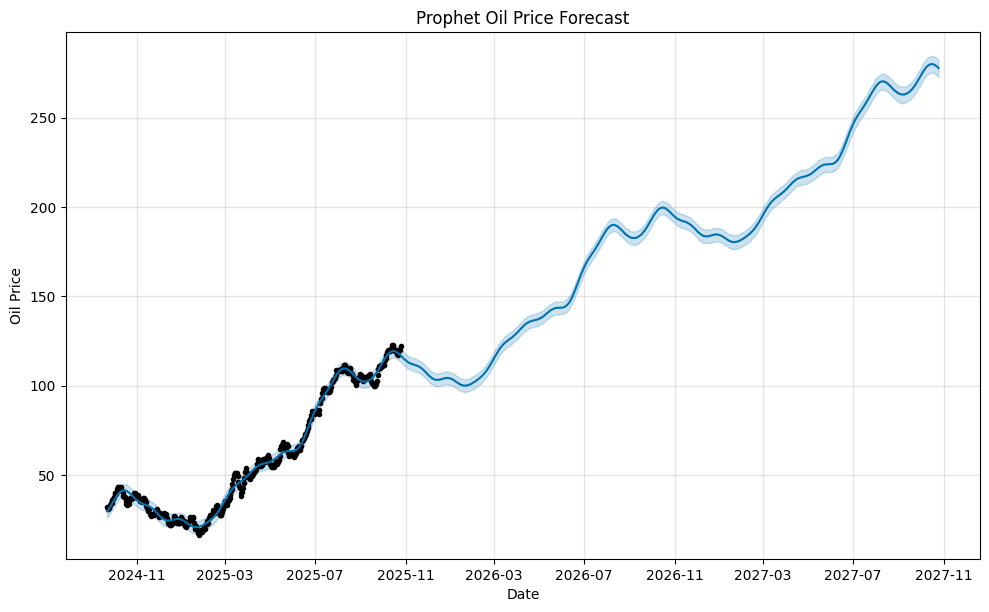

In [8]:

#  Prophet Forecast Plot


fig = model_prophet.plot(forecast)

plt.title("Prophet Oil Price Forecast")

plt.xlabel("Date")

plt.ylabel("Oil Price")

plt.show()

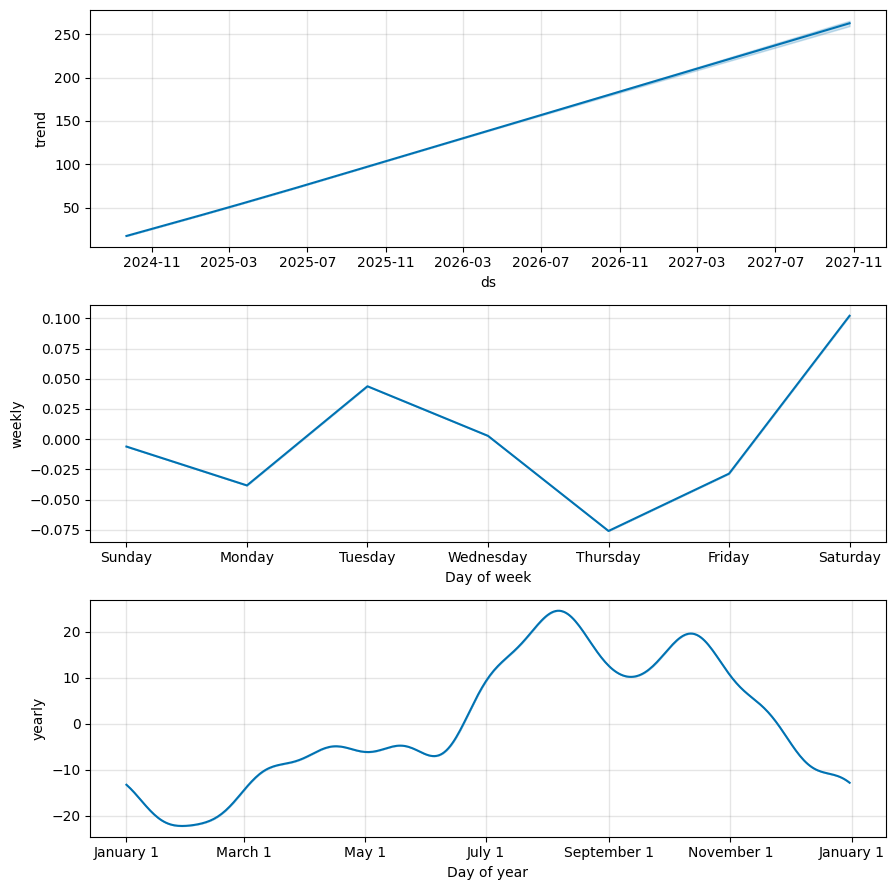

In [9]:

# Prophet Components


model_prophet.plot_components(forecast)

plt.show()

In [10]:
print("ARIMA RMSE:", rmse)
print("Prophet RMSE:", rmse_prophet)

ARIMA RMSE: 34928.073296785595
Prophet RMSE: 34.13911266526935
